In [28]:
# Input and Config
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = "../data/raw/student_mental_health_burnout_1M.csv"
output_dir = "../outputs/eda"
os.makedirs(output_dir, exist_ok=True)

sample_size = 50_000
sns.set_theme(style="whitegrid")

In [29]:
# Load Data
df_full = pd.read_csv(data_path)
df = df_full.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Full dataset : {df_full.shape[0]:,} rows x {df_full.shape[1]} cols")
print(f"Sample : {df.shape[0]:,} rows x {df.shape[1]} cols")

Full dataset : 1,000,000 rows x 20 cols
Sample : 50,000 rows x 20 cols


In [30]:
# Basic Info
print(df_full.dtypes)
df_full.isnull().sum()

age                       int64
gender                   object
academic_year             int64
study_hours_per_day     float64
exam_pressure           float64
academic_performance    float64
stress_level            float64
anxiety_score           float64
depression_score        float64
sleep_hours             float64
physical_activity       float64
social_support          float64
screen_time             float64
internet_usage          float64
financial_stress        float64
family_expectation      float64
burnout_score           float64
mental_health_index     float64
risk_level               object
dropout_risk            float64
dtype: object


age                     0
gender                  0
academic_year           0
study_hours_per_day     0
exam_pressure           0
academic_performance    0
stress_level            0
anxiety_score           0
depression_score        0
sleep_hours             0
physical_activity       0
social_support          0
screen_time             0
internet_usage          0
financial_stress        0
family_expectation      0
burnout_score           0
mental_health_index     0
risk_level              0
dropout_risk            0
dtype: int64

In [31]:
# Descriptive Statistics
df_full.describe().T.style.background_gradient(cmap="Blues")

,count,mean,std,min,25%,50%,75%,max
age,1000000.000000,22.996456,3.742579,17.000000,20.000000,23.000000,26.000000,29.000000
academic_year,1000000.000000,2.500782,1.117749,1.000000,2.000000,3.000000,4.000000,4.000000
study_hours_per_day,1000000.000000,5.001727,1.989340,0.000000,3.650644,4.998222,6.345532,14.000000
exam_pressure,1000000.000000,5.998810,1.548268,1.000000,4.944647,5.998906,7.051914,10.000000
academic_performance,1000000.000000,70.999135,5.660073,42.365714,67.180912,70.999914,74.820937,97.246309
stress_level,1000000.000000,4.246462,1.678998,0.000000,3.102593,4.244029,5.385464,10.000000
anxiety_score,1000000.000000,2.986413,1.509844,0.000000,1.923747,2.969514,4.014996,10.000000
depression_score,1000000.000000,1.274728,1.221273,0.000000,0.005198,1.047839,2.086397,8.530800
sleep_hours,1000000.000000,6.501713,1.472972,3.000000,5.491047,6.501938,7.514642,10.000000
physical_activity,1000000.000000,3.011153,1.463679,0.000000,1.990596,3.000619,4.011208,7.000000


stress_level stats: 
count    1000000.000000
mean           4.246462
std            1.678998
min            0.000000
25%            3.102593
50%            4.244029
75%            5.385464
max           10.000000
Name: stress_level, dtype: float64


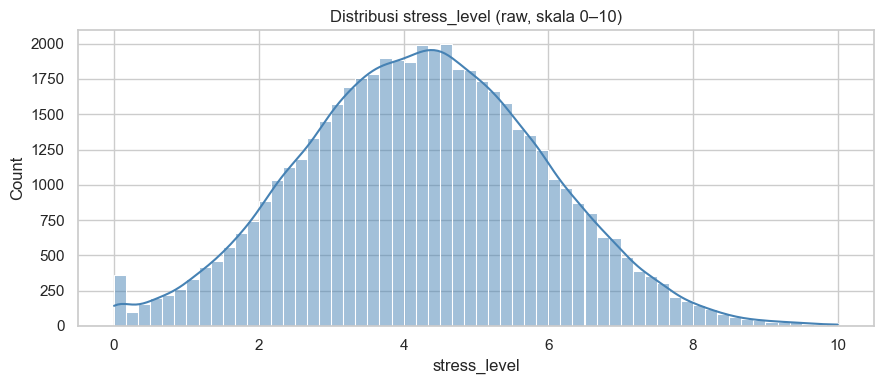

In [32]:
# Target Variables
print(f"stress_level stats: \n{df_full["stress_level"].describe()}")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["stress_level"], bins=60, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribusi stress_level (raw, skala 0–10)")
ax.set_xlabel("stress_level")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{output_dir}/stress_level_raw.png", dpi=150)
plt.show()

In [33]:
# Buat Target Kategori (Quantile Binning)
for frame in [df_full, df]:
    frame["stress_category"] = pd.qcut(
        frame["stress_level"],
        q=3,
        labels=["Low", "Moderate", "High"]
    )

print("Distribusi stress_category (full dataset) :")
vc = df_full["stress_category"].value_counts()
pct = df_full["stress_category"].value_counts(normalize=True) * 100
print(pd.DataFrame({"Count": vc, "Pct (%)": pct.round(2)}))

Distribusi stress_category (full dataset) :
                  Count  Pct (%)
stress_category                 
Moderate         333334    33.33
Low              333333    33.33
High             333333    33.33


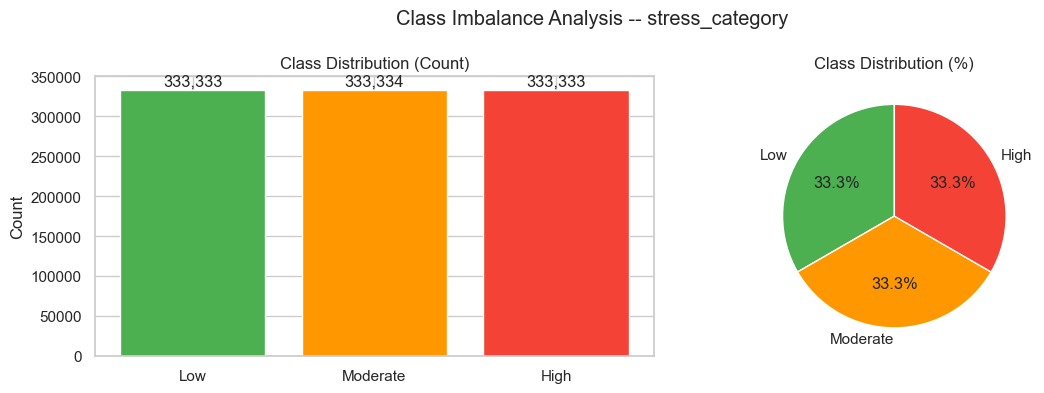

In [34]:
# Class Imbalance Analysis
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar count
ax = axes[0]
order = ["Low", "Moderate", "High"]
counts = df_full["stress_category"].value_counts()[order]
bars = ax.bar(order, counts, color=["#4CAF50", "#FF9800", "#F44336"])
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'{val:,}', ha='center', va='bottom')
ax.set_title("Class Distribution (Count)")
ax.set_ylabel("Count")

# Pie
axes[1].pie(
    counts, labels=order, autopct="%1.1f%%",
    colors=["#4CAF50", "#FF9800", "#F44336"],
    startangle=90
)
axes[1].set_title("Class Distribution (%)")

plt.suptitle("Class Imbalance Analysis -- stress_category")
plt.tight_layout()
plt.savefig(f"{output_dir}/class_distribution.png", dpi=150)
plt.show()

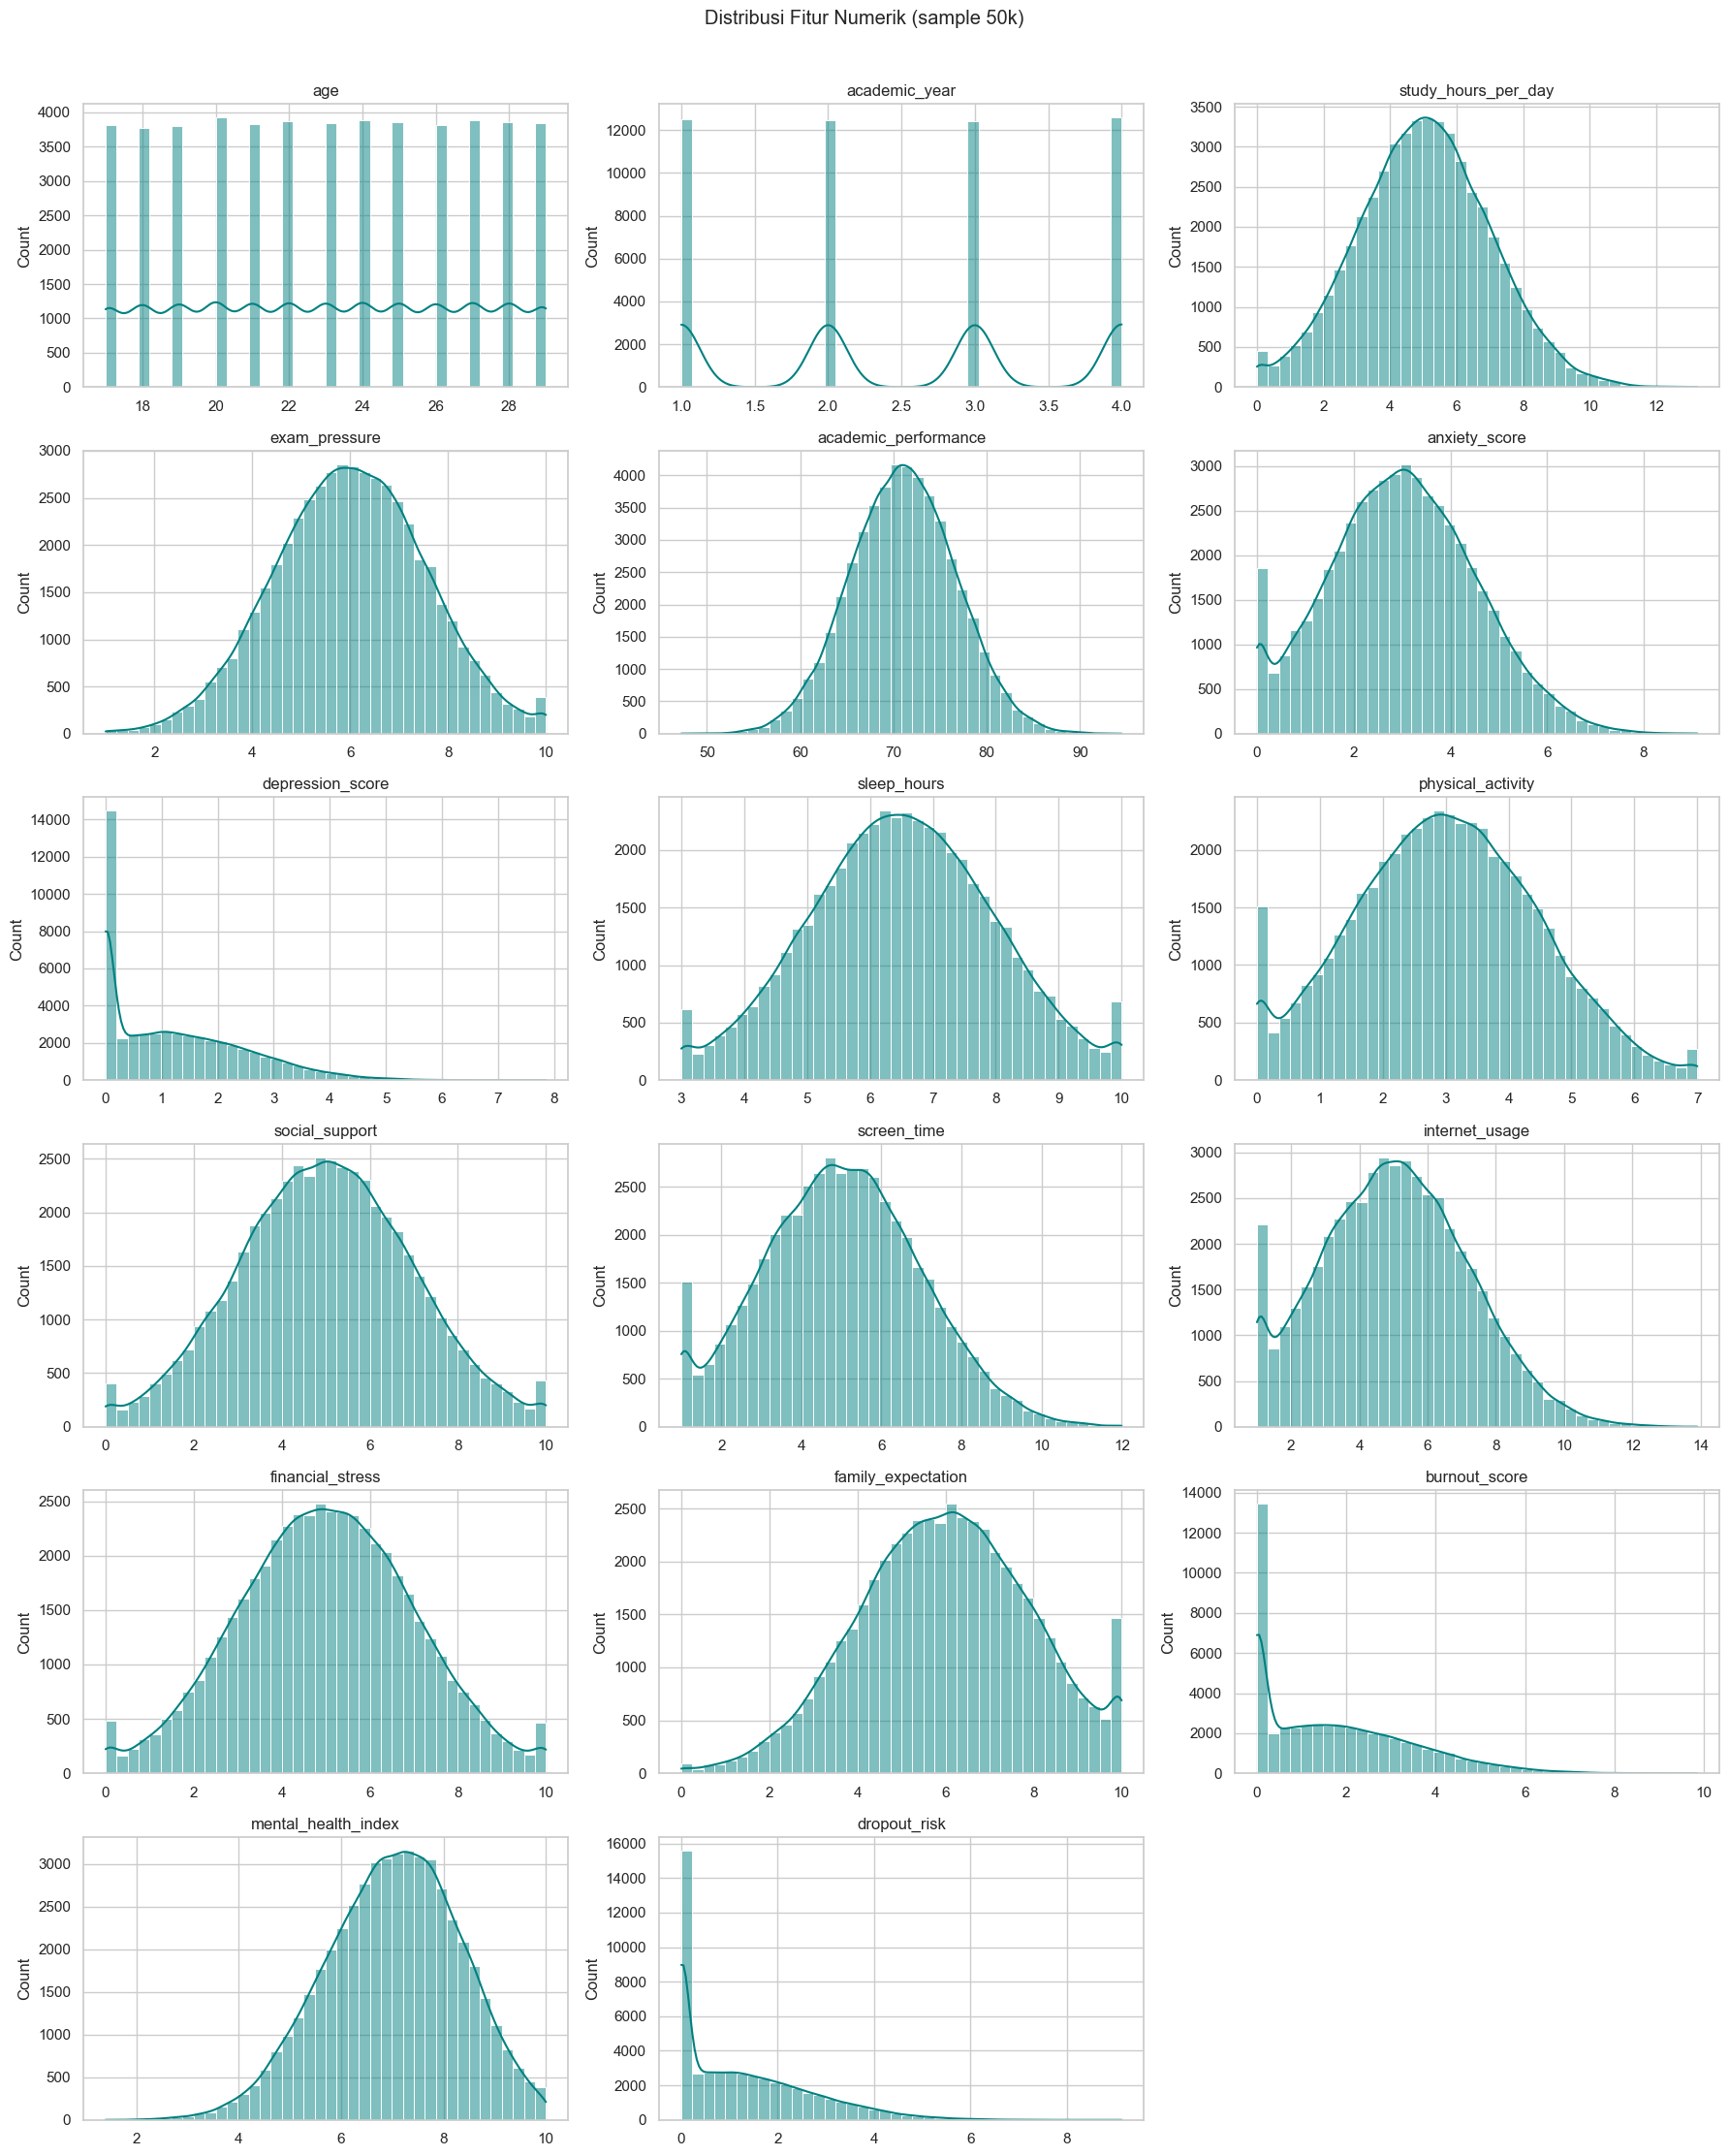

In [35]:
# Distribusi Fitur Numerik
numeric_features = [
    "age", "academic_year", "study_hours_per_day", "exam_pressure",
    "academic_performance", "anxiety_score", "depression_score",
    "sleep_hours", "physical_activity", "social_support",
    "screen_time", "internet_usage", "financial_stress",
    "family_expectation", "burnout_score", "mental_health_index",
    "dropout_risk"
]

fig, axes = plt.subplots(6, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], bins=40, kde=True, ax=axes[i], color="teal")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(len(numeric_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribusi Fitur Numerik (sample 50k)", y=1.01)
plt.tight_layout()
plt.savefig(f"{output_dir}/numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

C:\Users\zahra\AppData\Local\Temp\ipykernel_21748\3145392102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zahra\AppData\Local\Temp\ipykernel_21748\3145392102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zahra\AppData\Local\Temp\ipykernel_21748\3145392102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\zahra\AppData\Local\Temp\ipykernel_21748\3145392102.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

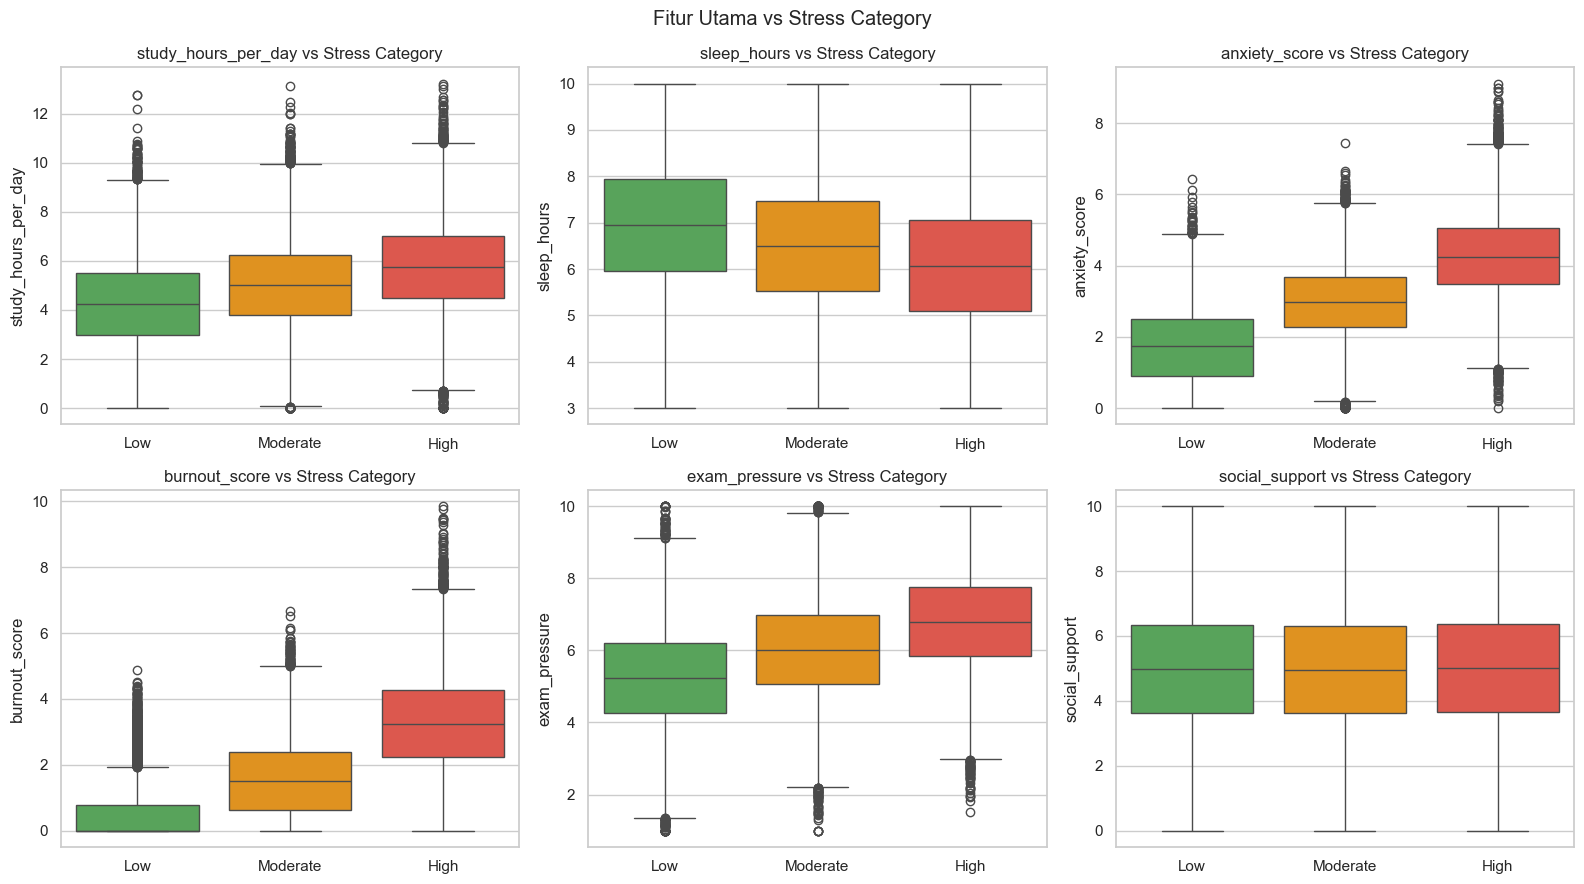

In [36]:
# Boxplot Feature & stress_category
key_features = [
    "study_hours_per_day", "sleep_hours", "anxiety_score",
    "burnout_score", "exam_pressure", "social_support"
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
order = ["Low", "Moderate", "High"]
palette = {"Low": "#4CAF50", "Moderate": "#FF9800", "High": "#F44336"}

for i, col in enumerate(key_features):
    sns.boxplot(
        data=df, x="stress_category", y=col,
        order=order, palette=palette, ax=axes[i]
    )
    axes[i].set_title(f"{col} vs Stress Category")
    axes[i].set_xlabel("")

plt.suptitle("Fitur Utama vs Stress Category")
plt.tight_layout()
plt.savefig(f"{output_dir}/boxplot_vs_target.png", dpi=150)
plt.show()

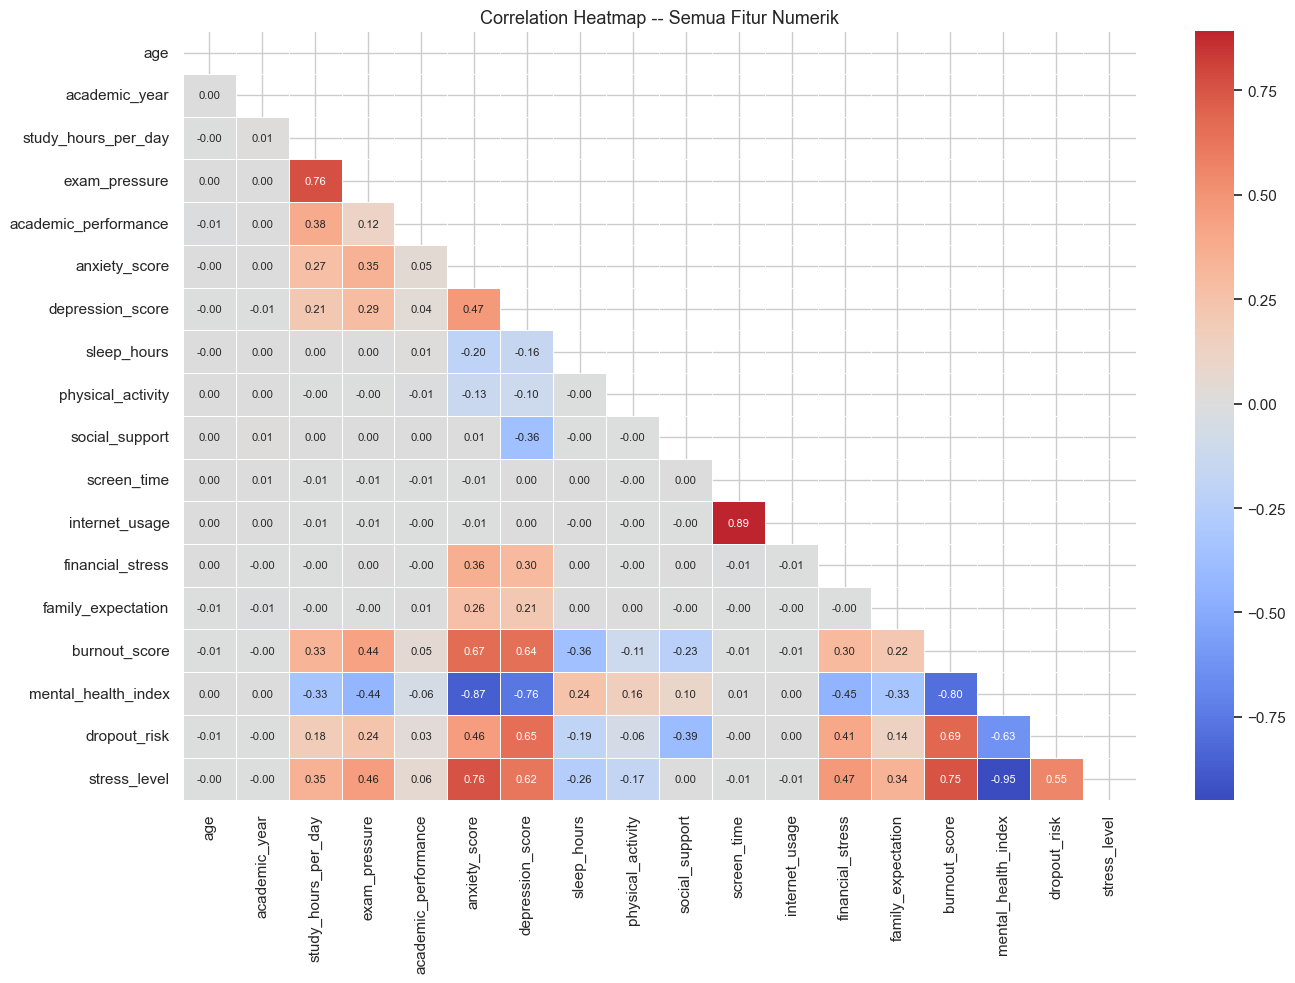

In [37]:
# Correlation Heatmap
plt.figure(figsize=(14, 10))
corr = df[numeric_features + ["stress_level"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5, annot_kws={"size": 8}
)
plt.title("Correlation Heatmap -- Semua Fitur Numerik", fontsize=13)
plt.tight_layout()
plt.savefig(f"{output_dir}/correlation_heatmap.png", dpi=150)
plt.show()

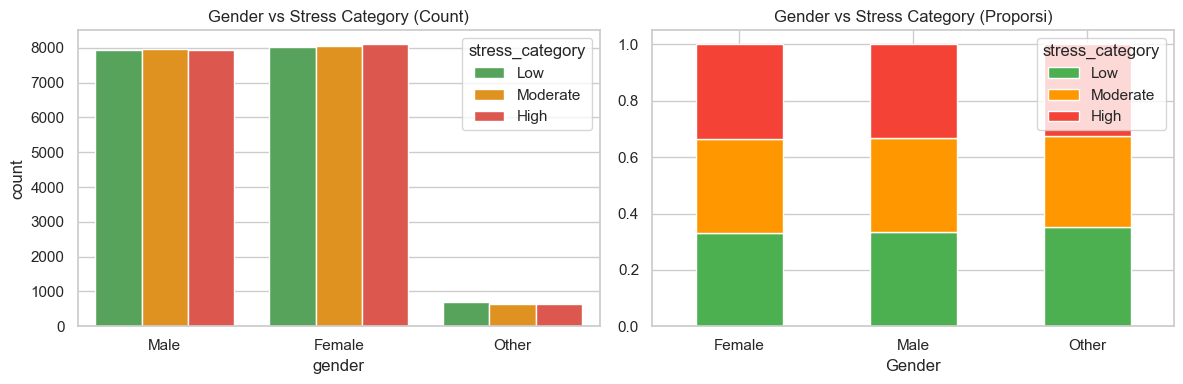

In [38]:
# Gender vs. Stress Category
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
order_cat = ["Low", "Moderate", "High"]

# Count
sns.countplot(
    data=df, x="gender", hue="stress_category",
    hue_order=order_cat,
    palette={"Low": "#4CAF50", "Moderate": "#FF9800", "High": "#F44336"},
    ax=axes[0]
)
axes[0].set_title("Gender vs Stress Category (Count)")

# Proporsi
gender_stress = (
    df.groupby(["gender", "stress_category"], observed=True)
    .size()
    .unstack()
    .div(df.groupby("gender", observed=True).size(), axis=0)
)
gender_stress[order_cat].plot(
    kind="bar", stacked=True,
    color=["#4CAF50", "#FF9800", "#F44336"],
    ax=axes[1]
)
axes[1].set_title("Gender vs Stress Category (Proporsi)")
axes[1].set_xlabel("Gender")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/gender_vs_stress.png", dpi=150)
plt.show()